In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv("/Mall_Customers.csv")
data.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data['Gender'] = data['Gender'].map({'Male':0, 'Female':1})
data.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [ ]:
data.describe()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.560000,38.850000,60.560000,50.200000
std,57.879185,0.497633,13.969007,26.264721,25.823522
min,1.000000,0.000000,18.000000,15.000000,1.000000
25%,50.750000,0.000000,28.750000,41.500000,34.750000
50%,100.500000,1.000000,36.000000,61.500000,50.000000
75%,150.250000,1.000000,49.000000,78.000000,73.000000
max,200.000000,1.000000,70.000000,137.000000,99.000000


In [ ]:
data['Gender'].mode()

,Gender
0,1


In [ ]:
data['Age'].mode()

,Age
0,32


In [ ]:
data['Annual Income (k$)'].mode()

,Annual Income (k$)
0,54
1,78


In [ ]:
data['Spending Score (1-100)'].mode()

,Spending Score (1-100)
0,42


In [ ]:
custsegment = data[['Annual Income (k$)','Spending Score (1-100)']]
custsegment.head(5)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
custsegmentscaled = scaler.fit_transform(custsegment)
custsegmentscaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
wcss=[]
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(custsegmentscaled)
  wcss.append(kmeans.inertia_)

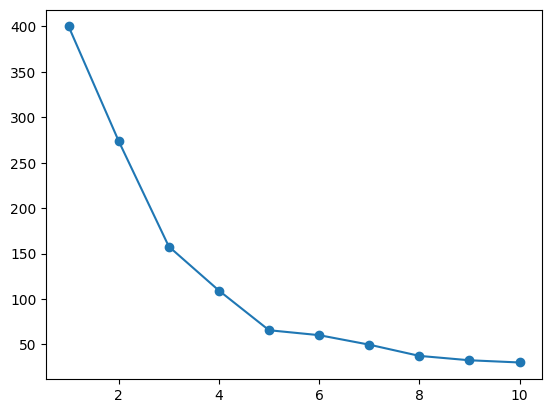

In [ ]:
plt.plot(range(1,11), wcss, marker='o')

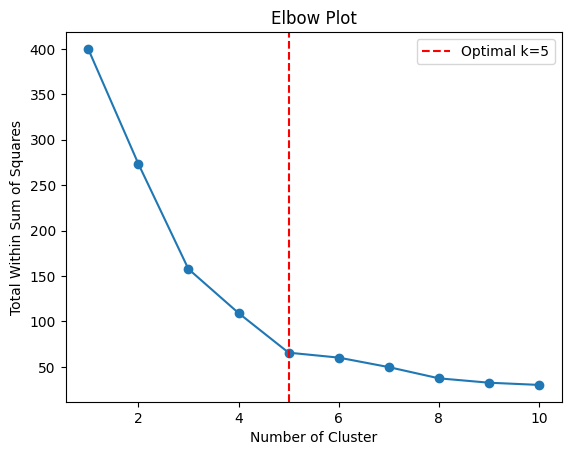

In [113]:
plt.plot(range(1,11), wcss, marker='o')
plt.axvline(x=5,
            color='red',
            linestyle='--',
            label='Optimal k=5')
plt.xlabel('Number of Cluster')
plt.ylabel('Total Within Sum of Squares')
plt.title('Elbow Plot')
plt.legend()
plt.show()

In [ ]:
kmeanscluster = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeanscluster.fit_predict(custsegmentscaled)
data.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,0,19,15,39,4
1,2,0,21,15,81,2
2,3,1,20,16,6,4
3,4,1,23,16,77,2
4,5,1,31,17,40,4


In [ ]:
np.array(data['Cluster'])

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

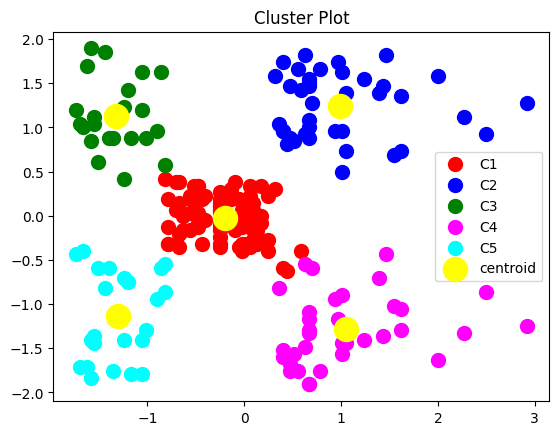

In [ ]:
plt.scatter(custsegmentscaled[data['Cluster']==0, 0], custsegmentscaled[data['Cluster']==0, 1], s=100, c='red', label='C1')
plt.scatter(custsegmentscaled[data['Cluster']==1, 0], custsegmentscaled[data['Cluster']==1, 1], s=100, c='blue', label='C2')
plt.scatter(custsegmentscaled[data['Cluster']==2, 0], custsegmentscaled[data['Cluster']==2, 1], s=100, c='green', label='C3')
plt.scatter(custsegmentscaled[data['Cluster']==3, 0], custsegmentscaled[data['Cluster']==3, 1], s=100, c='magenta', label='C4')
plt.scatter(custsegmentscaled[data['Cluster']==4, 0], custsegmentscaled[data['Cluster']==4, 1], s=100, c='cyan', label='C5')
plt.scatter(kmeanscluster.cluster_centers_[:,0], kmeanscluster.cluster_centers_[:,1], s=300, c='yellow', label='centroid')
plt.title('Cluster Plot')
plt.legend()
plt.show()